# 05 · Stress tests

| # | Test | Pass rule (fixed before running) |
|---|---|---|
| 1 | Cluster bootstrap CIs (isolates resampled) + exact VME bound | Tier 1 & 2 accuracy lower bound ≥ 0.92; EA lower bound ≥ 0.92 |
| 2 | +20% missing cells at inference | Tier 2 accuracy drop ≤ 0.03; AA drop ≤ 0.05 |
| 3 | +5% growth-imaging artefact wells | EA ≥ 0.92 and VME < 2% |
| 4 | +10% failed Gram reads | isolate-level Gram accuracy ≥ 0.98 |
| 5 | Gaussian noise 0.25 SD | Tier 2 accuracy drop ≤ 0.02 |
| 6 | Inoculum ± 0.5 log10 | Tier 2 accuracy change ≤ 0.01 |
| 7 | Subgroups (organism, drug) | worst Tier 2 accuracy ≥ 0.92; worst EA ≥ 0.92 |
| 8 | 10% Tier 2 label noise (retrain) | Tier 2 accuracy drop ≤ 0.02; AA drop ≤ 0.05 |
| 9 | Permutation test (retrain) | null AUC 0.5 ± 0.05; real − max null ≥ 0.30 |
| 10 | Learning curve (retrain) | Tier 2 Train-Test gap ≤ 0.03 |
| 11 | Grouped CV stability (retrain) | fold AUC SD ≤ 0.01; fold AA SD ≤ 0.05 |
| 12 | Input edge cases | finite probabilities, deterministic |

The full suite retrains models many times (about 8 minutes). Saved results are loaded unless `RUN_FULL = True` or they are missing.

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/gram-id-ast-ml


In [2]:
# Rebuild the isolate-grouped splits if they are missing (fresh clone)
from src.data import make_dataset
if not cfg.TRAIN_FILE.exists():
    make_dataset.main()
# Train everything once if the saved cascades are missing (about 6 minutes)
if not all(cfg.cascade_file(m).exists() for m in cfg.MODEL_NAMES):
    from src.features import build_features as bf
    from src.models import train_model as tm
    bf.run(); tm.run(); plt.close("all")
elif not cfg.SELECTED_FEATURES_FILE.exists():
    from src.features import build_features as bf
    bf.run(); plt.close("all")

from src.models import stress_test as st
names = ["bootstrap_ci", "corrupted_inputs", "subgroups", "label_noise", "permutation",
         "learning_curve", "cv_stability", "edge_cases"]
RUN_FULL = not all((cfg.TABLES_DIR / f"stress_{n}.csv").exists() for n in names)
if RUN_FULL:
    R = st.run(); plt.close("all")
    R = {**R, "bootstrap_ci": R["bootstrap"], "corrupted_inputs": R["corrupted"], "cv_stability": R["cv"],
         "edge_cases": R["edge"]}
else:
    R = {n: pd.read_csv(cfg.TABLES_DIR / f"stress_{n}.csv") for n in names}
    R["summary"] = pd.read_csv(cfg.TABLES_DIR / "stress_test_summary.csv")
print("computed" if RUN_FULL else "loaded saved", "stress-test results")

loaded saved stress-test results


## Scorecard

Model,SVM-RBF,Transformer,XGBoost
Test,,,
10 Tier 2 Train-Test gap,PASS,PASS,PASS
11 CV SD: T2 AUC / AA,PASS,PASS,PASS
12 input edge cases,PASS,PASS,PASS
1a Tier 1 & 2 accuracy CI lower,PASS,PASS,PASS
1b EA CI lower,PASS,PASS,PASS
2 +20% missing: T2 acc / AA drop,FAIL,FAIL,PASS
3 +5% growth artefacts: EA / VME,FAIL,PASS,FAIL
4 +10% Gram failures: isolate acc,PASS,PASS,PASS
5 0.25 SD noise: T2 acc drop,PASS,PASS,PASS


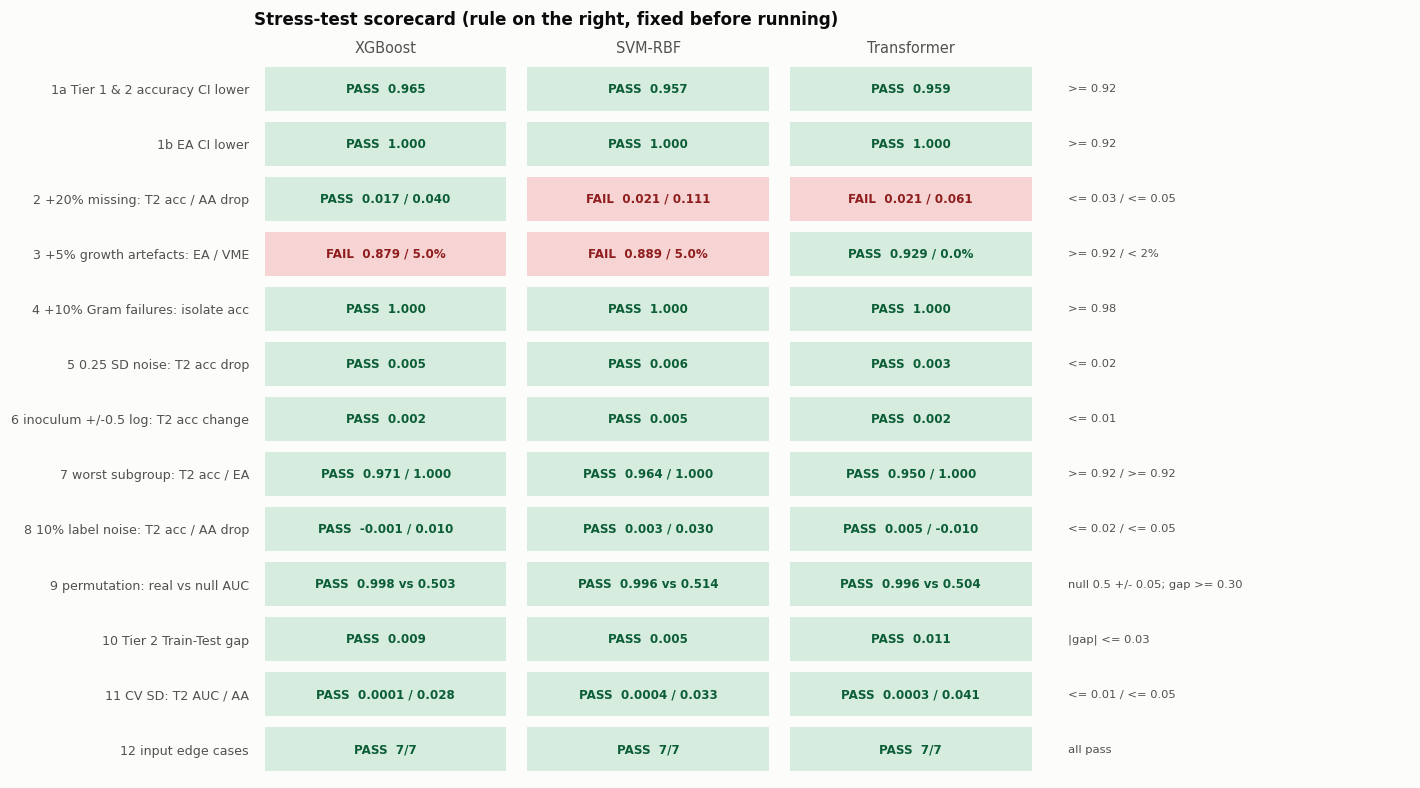

In [3]:
st.plot_scorecard(R["summary"])
R["summary"].pivot(index="Test", columns="Model", values="Result")

In [4]:
R["summary"][R["summary"].Result == "FAIL"]

,Model,Test,Value,Rule,Result
3,XGBoost,3 +5% growth artefacts: EA / VME,0.879 / 5.0%,>= 0.92 / < 2%,FAIL
15,SVM-RBF,2 +20% missing: T2 acc / AA drop,0.021 / 0.111,<= 0.03 / <= 0.05,FAIL
16,SVM-RBF,3 +5% growth artefacts: EA / VME,0.889 / 5.0%,>= 0.92 / < 2%,FAIL
28,Transformer,2 +20% missing: T2 acc / AA drop,0.021 / 0.061,<= 0.03 / <= 0.05,FAIL


## 1. Uncertainty

estimate                      ci_low                     ci_high                    
Model   SVM-RBF Transformer XGBoost SVM-RBF Transformer XGBoost SVM-RBF Transformer XGBoost
Metric                                                                                     
AA        0.970       0.899   0.949   0.935       0.838   0.907   1.000       0.952   0.988
CA        1.000       0.980   0.980   1.000       0.951   0.946   1.000       1.000   1.000
EA        1.000       1.000   1.000   1.000       1.000   1.000   1.000       1.000   1.000
T1_acc    0.968       0.968   0.973   0.957       0.959   0.965   0.977       0.977   0.980
T2_acc    0.983       0.979   0.985   0.976       0.972   0.978   0.989       0.987   0.991
VME       0.000       0.000   0.000   0.000       0.000   0.000   0.088       0.088   0.088

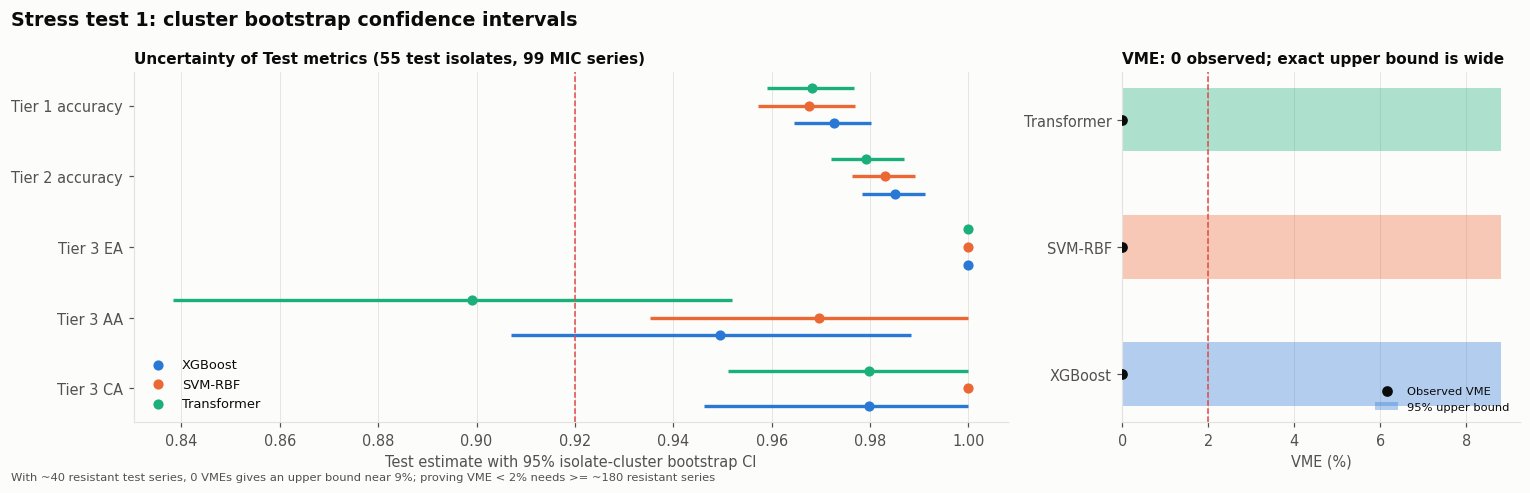

In [5]:
st.plot_bootstrap(R["bootstrap_ci"])
R["bootstrap_ci"].pivot(index="Metric", columns="Model", values=["estimate", "ci_low", "ci_high"]).round(3)

With about 40 resistant Test series, **0 VMEs still leaves an exact 95% upper bound near 9%**. Showing VME < 2% with 95% confidence would need roughly 180+ resistant series with no VME. This is a sample-size limit, not a model failure.

## 2-6. Corrupted inputs

AA                          EA                      T2_acc                         VME                    
Model                  SVM-RBF Transformer XGBoost SVM-RBF Transformer XGBoost SVM-RBF Transformer XGBoost SVM-RBF Transformer XGBoost
test            level                                                                                                                 
gram_failure     0.000   0.970       0.899   0.949   1.000       1.000   1.000   0.983       0.979   0.985   0.000       0.000   0.000
                 0.050   0.939       0.879   0.929   1.000       1.000   1.000   0.972       0.968   0.975   0.000       0.000   0.000
                 0.100   0.889       0.848   0.909   0.960       0.990   1.000   0.963       0.958   0.968   0.000       0.000   0.000
                 0.200   0.838       0.808   0.838   0.929       0.949   0.929   0.954       0.950   0.958   0.000       0.000   0.050
growth_artefact  0.000   0.970       0.899   0.949   1.000       1.000   1.000   0.983       0.979   0.985   0.000       0.000   0.000
                 0.025   0.848       0.828   0.818   0.939       0.970   0.929   0.956       0.952   0.957   0.050       0.000   0.075
                 0.050   0.828       0.788   0.788   0.889       0.929   0.879   0.943       0.938   0.943   0.050       0.000   0.050
                 0.100   0.758       0.707   0.747   0.919       0.919   0.909   0.899       0.895   0.898   0.025       0.000   0.050
inoculum_shift  -0.500   0.869       0.899   0.929   0.970       1.000   0.990   0.979       0.981   0.987   0.050       0.000   0.000
                 0.000   0.970       0.899   0.949   1.000       1.000   1.000   0.983       0.979   0.985   0.000       0.000   0.000
                 0.500   0.929       0.899   0.949   0.990       1.000   1.000   0.982       0.981   0.986   0.000       0.000   0.000
missing          0.000   0.970       0.899   0.949   1.000       1.000   1.000   0.983       0.979   0.985   0.000       0.000   0.000
                 0.100   0.889       0.859   0.929   0.990       0.980   0.990   0.975       0.973   0.984   0.000       0.000   0.000
                 0.200   0.859       0.838   0.909   0.960       0.970   0.980   0.962       0.958   0.968   0.000       0.000   0.000
                 0.300   0.808       0.798   0.909   0.939       0.949   0.970   0.942       0.944   0.967   0.000       0.000   0.000
noise_sd         0.000   0.970       0.899   0.949   1.000       1.000   1.000   0.983       0.979   0.985   0.000       0.000   0.000
                 0.100   0.939       0.899   0.939   1.000       1.000   1.000   0.980       0.981   0.986   0.000       0.000   0.000
                 0.250   0.879       0.889   0.899   0.980       0.990   1.000   0.977       0.977   0.980   0.000       0.000   0.000
                 0.500   0.788       0.798   0.828   0.939       0.970   0.960   0.953       0.961   0.963   0.075       0.025   0.025

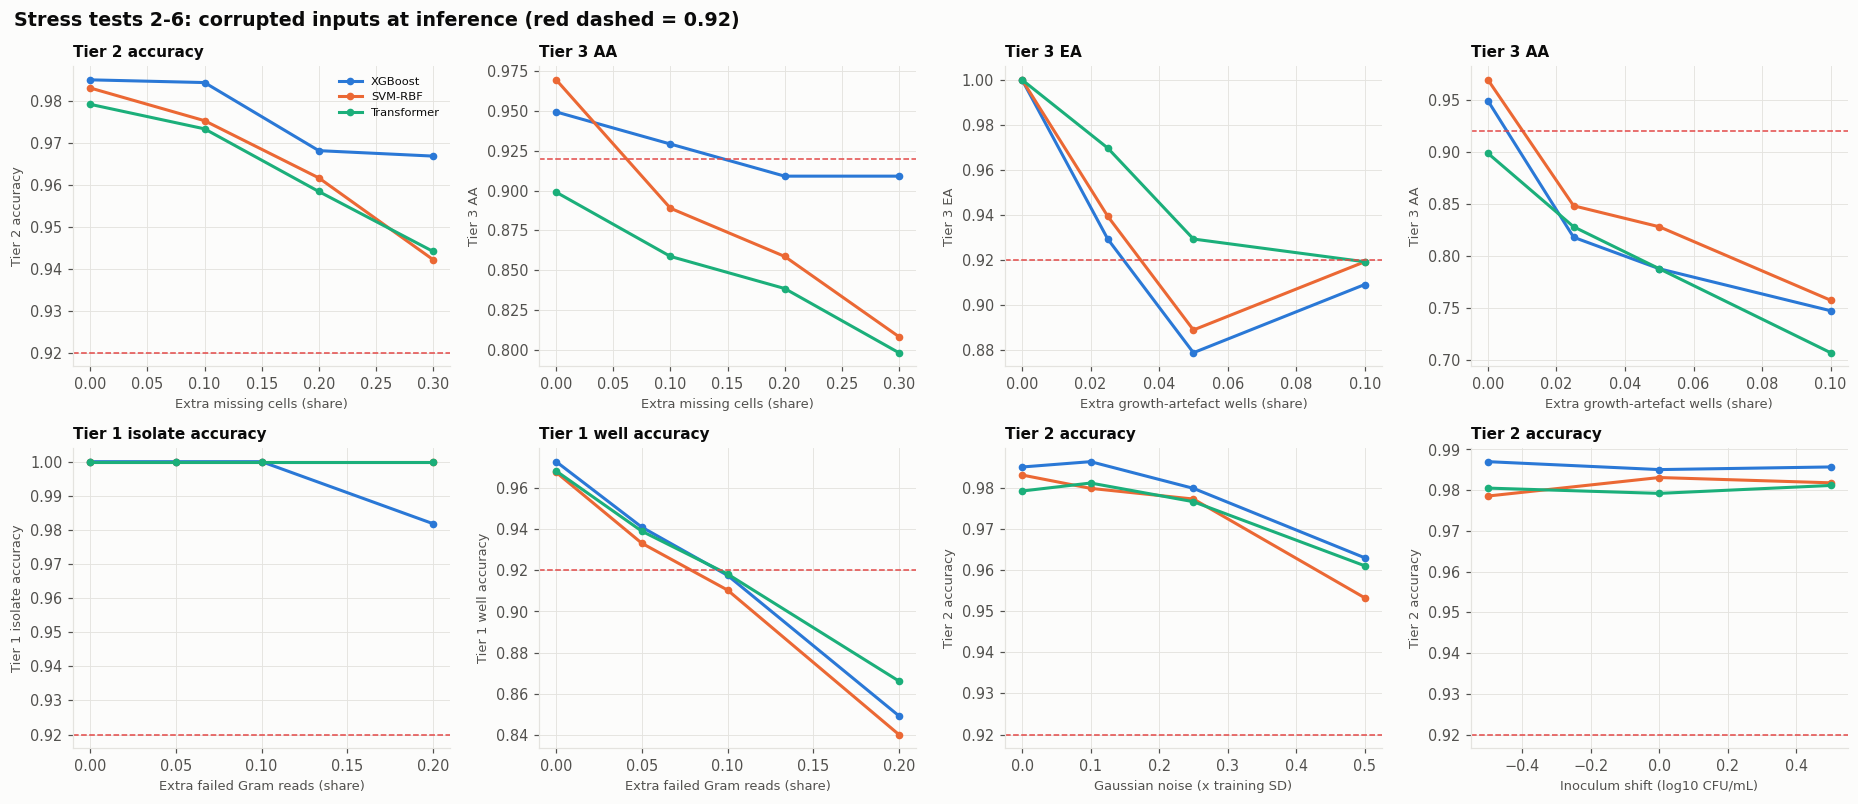

In [6]:
st.plot_perturbations(R["corrupted_inputs"])
R["corrupted_inputs"].pivot_table(index=["test", "level"], columns="Model", values=["T2_acc", "EA", "AA", "VME"]).round(3)

**Findings.** The cascade tolerates noise, inoculum shifts and failed Gram reads well (isolate pooling). MIC calls are the weak point under **extra growth-imaging artefacts**: at +5% extra artefact wells, EA falls to about 0.88-0.93, and XGBoost and SVM each record 2 VMEs out of 40. That happens when an artefact lands on a well next to the MIC. **Extra missing data** mainly lowers exact agreement (AA). Practical consequences: image-quality control that flags artefact wells, and a rule that sends series with conflicting wells for re-reading.

## 7. Subgroups

Model                                       SVM-RBF  Transformer  XGBoost
level    group                      metric                               
drug     Ampicillin                 AA        0.938        0.938    1.000
                                    EA        1.000        1.000    1.000
         Ceftriaxone                AA        1.000        0.875    0.875
                                    EA        1.000        1.000    1.000
         Daptomycin                 AA        1.000        0.944    1.000
                                    EA        1.000        1.000    1.000
         Meropenem                  AA        0.941        0.765    0.941
                                    EA        1.000        1.000    1.000
         Oxacillin                  AA        1.000        1.000    0.941
                                    EA        1.000        1.000    1.000
         Vancomycin                 AA        0.933        0.867    0.933
                                    EA        1.000        1.000    1.000
organism Enterococcus faecalis      AA        1.000        0.968    1.000
                                    EA        1.000        1.000    1.000
                                    T2_acc    0.982        0.978    0.985
         Enterococcus faecium       AA        0.929        0.857    0.929
                                    EA        1.000        1.000    1.000
                                    T2_acc    0.967        0.967    0.983
         Escherichia coli           T2_acc    0.991        0.994    1.000
         Klebsiella pneumoniae      T2_acc    0.993        0.993    0.993
         Pseudomonas aeruginosa     T2_acc    0.990        0.995    0.985
         Staphylococcus aureus      AA        1.000        0.857    0.857
                                    EA        1.000        1.000    1.000
                                    T2_acc    0.988        0.971    0.971
         Staphylococcus epidermidis AA        0.923        0.885    1.000
                                    EA        1.000        1.000    1.000
                                    T2_acc    0.964        0.950    0.973

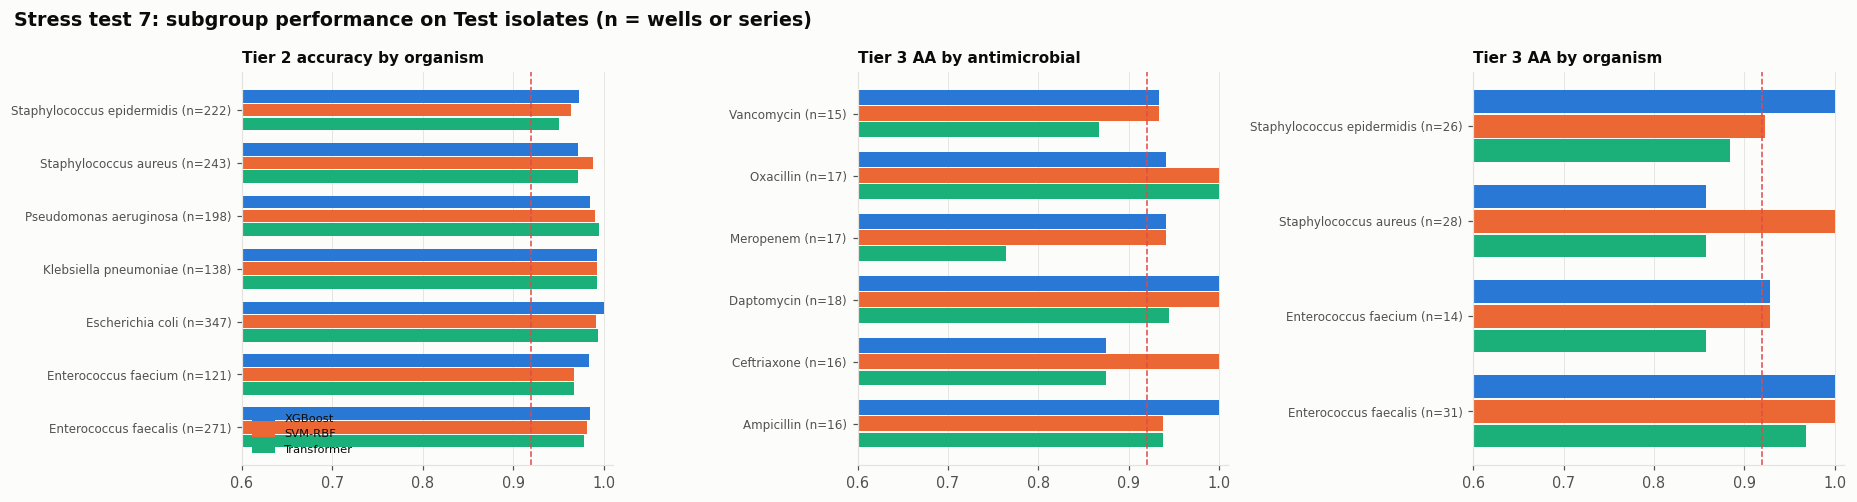

In [7]:
st.plot_subgroups(R["subgroups"])
R["subgroups"].pivot_table(index=["level", "group", "metric"], columns="Model", values="value").round(3)

## 8-11. Retraining checks

,Model,T2_acc_clean,T2_acc_noisy,AA_clean,AA_noisy,EA_noisy,VME_noisy
0,XGBoost,0.985,0.986,0.949,0.939,1.00,0.0
1,SVM-RBF,0.983,0.981,0.970,0.939,0.99,0.0
2,Transformer,0.979,0.975,0.899,0.909,1.00,0.0


T2_auc              AA              EA        
               mean     std    mean     std    mean     std
Model                                                      
SVM-RBF      0.9988  0.0004  0.9423  0.0327  0.9944  0.0077
Transformer  0.9989  0.0003  0.9341  0.0406  0.9887  0.0154
XGBoost      0.9991  0.0001  0.9590  0.0276  0.9944  0.0077

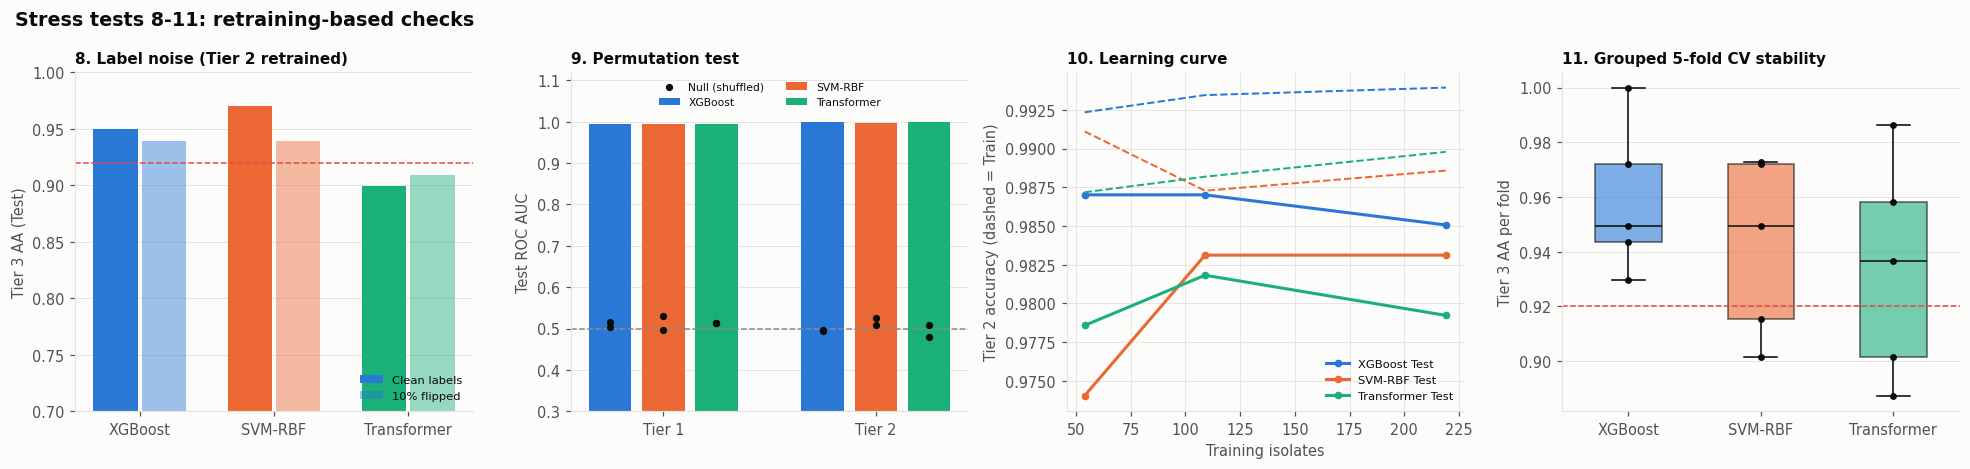

In [8]:
st.plot_retraining(R["label_noise"], R["permutation"], R["learning_curve"], R["cv_stability"])
display(R["label_noise"].round(3))
display(R["cv_stability"].groupby("Model")[["T2_auc", "AA", "EA"]].agg(["mean", "std"]).round(4))

## 12. Edge cases

In [9]:
R["edge_cases"]

,Model,case,passed,detail
0,XGBoost,all_features_missing,True,"2 MIC calls, P range 0.89-0.99"
1,XGBoost,extreme_values_x50,True,"0 MIC calls, P range 0.00-0.73"
2,XGBoost,extreme_negative_values,True,"0 MIC calls, P range 0.00-0.44"
3,XGBoost,unseen_antimicrobial,True,"0 MIC calls, P range 0.00-1.00"
4,XGBoost,unseen_categories,True,"0 MIC calls, P range 0.00-1.00"
5,XGBoost,single_well_series,True,"0 MIC calls, P range 0.40-1.00"
6,XGBoost,deterministic_repeat_call,True,max diff 0.0e+00
7,SVM-RBF,all_features_missing,True,"2 MIC calls, P range 0.92-1.00"
8,SVM-RBF,extreme_values_x50,True,"0 MIC calls, P range 0.00-0.01"
9,SVM-RBF,extreme_negative_values,True,"2 MIC calls, P range 0.00-0.78"
